In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat


In [98]:
CE_BASELINE_CSV = "CE_distance_corrected.csv"  # CE = N–E (N is your "C" == North)
WC_BASELINE_CSV = "WC_distance_corrected.csv"      # WC = W–N
WE_BASELINE_CSV = "WE_distance_corrected.csv"      # WE = W–E

PN_CSV = "Pn_drifcor.csv"   # North (C) pressure
PE_CSV = "Pe_drifcor.csv"   # East pressure
PW_CSV = "Pw_drifcor.csv"   # West pressure

EQ_MAT = "ForMaleenV4-1.mat"   # earthquakes (east/west), optional but recommended

# Analysis settings
BASELINE_MA_COL = "Moving Average (cm)"  # baseline-file 30-day moving average column
EXCLUDE_FIRST_DAYS = 30
ASOF_TOLERANCE = "2H"  # when aligning pressures (and EQ binned series) to baseline timeline

# Outputs
OUT_MASTER_CSV = "axial_master_timeseries_built_from_scratch.csv"
OUT_AREA_CSV   = "axial_triangle_area_areal_strain_excl_first30d.csv"
OUT_STRAIN_CSV = "axial_triangle_full2D_strain_excl_first30d.csv"


In [99]:
# =========================
# Cell 3 — helper functions
# =========================
def find_time_column(df: pd.DataFrame) -> str:
    for c in df.columns:
        lc = c.lower()
        if any(k in lc for k in ["time", "date", "datetime", "timestamp"]):
            return c
    return df.columns[0]

def read_time_indexed_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    tcol = find_time_column(df)
    df[tcol] = pd.to_datetime(df[tcol], utc=True, errors="coerce")
    df = df.dropna(subset=[tcol]).sort_values(tcol).set_index(tcol)
    # average duplicate timestamps (if any)
    df = df.groupby(level=0).mean(numeric_only=True)
    return df

def pick_numeric_col(df: pd.DataFrame, preferred_keywords=None, banned_keywords=None) -> str:
    """
    Pick a numeric column by scoring names. Useful for pressure CSVs where the value
    column name may vary.
    """
    preferred_keywords = preferred_keywords or []
    banned_keywords = banned_keywords or ["time", "date", "datetime", "timestamp"]

    best = None
    best_score = -1e9
    for c in df.columns:
        lc = c.lower()
        if any(b in lc for b in banned_keywords):
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        if np.isfinite(s).sum() < 20:
            continue
        score = 0
        for kw in preferred_keywords:
            if kw in lc:
                score += 3
        # small preference for "drift" or "cor" style columns
        for kw in ["drift", "cor", "correct", "value", "pressure", "kpa", "pa", "mbar", "db"]:
            if kw in lc:
                score += 1
        if score > best_score:
            best_score = score
            best = c
    if best is None:
        raise ValueError(f"Could not find a numeric value column in: {list(df.columns)}")
    return best

def merge_asof_series(master_time: pd.Series, series: pd.Series, tolerance="2H") -> pd.Series:
    """
    Align a time-indexed series onto a master time axis using nearest match within tolerance.
    Returns a series indexed by master_time.
    """
    left = pd.DataFrame({"time": pd.to_datetime(master_time, utc=True)}).sort_values("time")
    right = series.dropna().reset_index()
    right.columns = ["time_r", series.name]
    right = right.sort_values("time_r")

    out = pd.merge_asof(
        left, right,
        left_on="time", right_on="time_r",
        direction="nearest",
        tolerance=pd.Timedelta(tolerance)
    )
    out = out.drop(columns=["time_r"])
    return out.set_index("time")[series.name]

def heron_area(a: pd.Series, b: pd.Series, c: pd.Series) -> pd.Series:
    s = 0.5 * (a + b + c)
    A2 = s * (s - a) * (s - b) * (s - c)
    return np.sqrt(np.maximum(A2, 0.0))

def embed_triangle(CE: float, WC: float, WE: float):
    """
    Embed triangle in 2D with:
      N at (0,0)
      E at (CE,0)
      W at (xW,yW)
    using CE=N–E, WC=W–N, WE=W–E.

    Returns (xW, yW) or (nan, nan) if invalid geometry.
    """
    a, b, c = CE, WC, WE
    if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(c):
        return np.nan, np.nan
    if a <= 0 or b <= 0 or c <= 0:
        return np.nan, np.nan
    if (a + b <= c) or (a + c <= b) or (b + c <= a):
        return np.nan, np.nan

    xW = (a*a + b*b - c*c) / (2*a)
    y2 = b*b - xW*xW
    if y2 < 0:
        if y2 > -1e-6:
            y2 = 0.0
        else:
            return np.nan, np.nan
    return xW, np.sqrt(y2)

def matlab_datenum_to_datetime_utc(dn):
    """
    Convert MATLAB datenum (days since 0000-01-00) to pandas datetime UTC.
    MATLAB datenum 719529 == 1970-01-01
    """
    dn = np.asarray(dn).astype(float)
    return pd.to_datetime(dn - 719529, unit="D", origin="unix", utc=True, errors="coerce")

def event_counts_on_timeline(event_times_utc: pd.DatetimeIndex, timeline_utc: pd.DatetimeIndex) -> pd.Series:
    """
    Bin event times into the sampling intervals implied by timeline_utc.
    Uses half-interval edges between consecutive timeline points.
    Returns counts per timeline timestamp.
    """
    timeline = pd.DatetimeIndex(pd.to_datetime(timeline_utc, utc=True)).sort_values()
    events = pd.DatetimeIndex(pd.to_datetime(event_times_utc, utc=True)).sort_values()

    if len(timeline) < 2:
        return pd.Series(index=timeline, dtype=float)

    # Build bin edges as midpoints between consecutive timeline samples
    mid = timeline[:-1] + (timeline[1:] - timeline[:-1]) / 2
    edges = mid.insert(0, timeline[0] - (mid[0] - timeline[0]))
    edges = edges.append(pd.Index([timeline[-1] + (timeline[-1] - mid[-1])]))

    # Bin events
    idx = np.searchsorted(edges.values.astype("datetime64[ns]"), events.values.astype("datetime64[ns]"), side="right") - 1
    counts = np.zeros(len(timeline), dtype=int)
    valid = (idx >= 0) & (idx < len(timeline))
    np.add.at(counts, idx[valid], 1)

    return pd.Series(counts, index=timeline, name="event_count")


In [100]:
def embed_triangle_EW(CE: float, WC: float, WE: float):
    """
    Embed triangle in 2D with:
      E at (0,0)
      W at (WE,0)   <-- EW is the x-axis
      N at (xN,yN)
    using:
      CE = N–E
      WC = W–N
      WE = W–E

    Returns (xN, yN) or (nan, nan) if invalid geometry.
    """
    EN, WN, EW = CE, WC, WE

    if not (np.isfinite(EN) and np.isfinite(WN) and np.isfinite(EW)):
        return np.nan, np.nan
    if EN <= 0 or WN <= 0 or EW <= 0:
        return np.nan, np.nan
    if (EN + WN <= EW) or (EN + EW <= WN) or (WN + EW <= EN):
        return np.nan, np.nan

    # Coordinate of N relative to E with EW along +x
    xN = (EN*EN + EW*EW - WN*WN) / (2.0 * EW)
    y2 = EN*EN - xN*xN
    if y2 < 0:
        if y2 > -1e-6:
            y2 = 0.0
        else:
            return np.nan, np.nan

    return xN, np.sqrt(y2)  # choose +sqrt for consistent orientation


In [101]:
# =========================
# Cell 4 (REPLACE) — load baselines and align CE/WC/WE MA onto one timeline
# =========================
ce = read_time_indexed_csv(CE_BASELINE_CSV)
wc = read_time_indexed_csv(WC_BASELINE_CSV)
we = read_time_indexed_csv(WE_BASELINE_CSV)

CE_ma = pd.to_numeric(ce[BASELINE_MA_COL], errors="coerce").rename("CE_ma_cm").dropna()
WC_ma = pd.to_numeric(wc[BASELINE_MA_COL], errors="coerce").rename("WC_ma_cm").dropna()
WE_ma = pd.to_numeric(we[BASELINE_MA_COL], errors="coerce").rename("WE_ma_cm").dropna()

# Use CE timestamps as the master baseline timeline
tline = CE_ma.index

WC_ma_a = merge_asof_series(tline.to_series(), WC_ma, tolerance=ASOF_TOLERANCE)
WE_ma_a = merge_asof_series(tline.to_series(), WE_ma, tolerance=ASOF_TOLERANCE)

baseline_master = pd.DataFrame({
    "CE_ma_cm": CE_ma.reindex(tline),
    "WC_ma_cm": WC_ma_a,
    "WE_ma_cm": WE_ma_a,
}).dropna().sort_index()

print("baseline_master:", baseline_master.shape, type(baseline_master.index), baseline_master.index.min(), baseline_master.index.max())
baseline_master.head()


baseline_master: (6225, 3) <class 'pandas.core.indexes.datetimes.DatetimeIndex'> 2022-09-01 19:30:00+00:00 2025-08-09 03:30:00+00:00


,CE_ma_cm,WC_ma_cm,WE_ma_cm
2022-09-01 19:30:00+00:00,164217.749477,176572.290310,326038.486107
2022-09-01 23:30:00+00:00,164214.415689,176571.428688,326036.027338
2022-09-02 03:30:00+00:00,164215.129703,176569.816675,326034.194822
2022-09-02 11:30:00+00:00,164215.635646,176568.972612,326032.683042
2022-09-02 15:30:00+00:00,164215.080930,176568.969179,326032.425465


In [102]:
# =========================
# Cell 5 — load pressures and compute differential pressures (Pn-Pe etc.)
# =========================
pn = read_time_indexed_csv(PN_CSV)
pe = read_time_indexed_csv(PE_CSV)
pw = read_time_indexed_csv(PW_CSV)

# auto-pick one numeric column from each pressure file
pn_val_col = pick_numeric_col(pn, preferred_keywords=["drift", "cor", "correct", "pressure", "value"])
pe_val_col = pick_numeric_col(pe, preferred_keywords=["drift", "cor", "correct", "pressure", "value"])
pw_val_col = pick_numeric_col(pw, preferred_keywords=["drift", "cor", "correct", "pressure", "value"])

Pn = pd.to_numeric(pn[pn_val_col], errors="coerce").rename("Pn")
Pe = pd.to_numeric(pe[pe_val_col], errors="coerce").rename("Pe")
Pw = pd.to_numeric(pw[pw_val_col], errors="coerce").rename("Pw")

# align onto baseline timeline (nearest within tolerance)
tline = baseline_master.index
Pn_a = merge_asof_series(tline.to_series(), Pn, tolerance=ASOF_TOLERANCE)
Pe_a = merge_asof_series(tline.to_series(), Pe, tolerance=ASOF_TOLERANCE)
Pw_a = merge_asof_series(tline.to_series(), Pw, tolerance=ASOF_TOLERANCE)

dP_NE = (Pn_a - Pe_a).rename("dP_NE")  # Pn - Pe
dP_NW = (Pn_a - Pw_a).rename("dP_NW")  # Pn - Pw
dP_EW = (Pe_a - Pw_a).rename("dP_EW")  # Pe - Pw

pn_val_col, pe_val_col, pw_val_col


('pressure_kPa', 'pressure_kPa', 'pressure_kPa')

In [103]:
# =========================
# Cell 6 — load earthquakes from .mat (auto-detect east/west time arrays)
# =========================
mat = loadmat(EQ_MAT, squeeze_me=True, struct_as_record=False)

# collect candidate arrays that look like MATLAB datenums
candidates = {}
for k, v in mat.items():
    if k.startswith("__"):
        continue
    arr = np.asarray(v)
    if arr.dtype.kind in "fi" and arr.ndim >= 1:
        flat = arr.ravel()
        # heuristic: MATLAB datenums are typically ~7e5–8e5 for modern dates
        finite = flat[np.isfinite(flat)]
        if finite.size > 10 and np.nanmedian(finite) > 600000 and np.nanmedian(finite) < 900000:
            candidates[k] = finite

# Try to pick "east" and "west" by name
east_key = None
west_key = None
for k in candidates.keys():
    lk = k.lower()
    if east_key is None and ("east" in lk or lk.endswith("_e") or "eqe" in lk):
        east_key = k
    if west_key is None and ("west" in lk or lk.endswith("_w") or "eqw" in lk):
        west_key = k

# Fallback: if not found, just leave None and proceed
eq_e_times = pd.DatetimeIndex([])
eq_w_times = pd.DatetimeIndex([])

if east_key is not None:
    eq_e_times = pd.DatetimeIndex(matlab_datenum_to_datetime_utc(candidates[east_key])).dropna()
if west_key is not None:
    eq_w_times = pd.DatetimeIndex(matlab_datenum_to_datetime_utc(candidates[west_key])).dropna()

print("Detected EQ keys:", {"east_key": east_key, "west_key": west_key})
print("EQ counts:", {"east_events": len(eq_e_times), "west_events": len(eq_w_times)})


Detected EQ keys: {'east_key': None, 'west_key': None}
EQ counts: {'east_events': 0, 'west_events': 0}


In [104]:
# =========================
# Cell 7 (REPLACE) — build master dataframe (from scratch)
# =========================
master = baseline_master.copy()

# pressures already aligned in Cell 5 (Pn_a, Pe_a, Pw_a, dP_NE, dP_NW, dP_EW)
master = master.join(Pn_a.rename("Pn"), how="left")
master = master.join(Pe_a.rename("Pe"), how="left")
master = master.join(Pw_a.rename("Pw"), how="left")
master = master.join(dP_NE, how="left")
master = master.join(dP_NW, how="left")
master = master.join(dP_EW, how="left")

# EQ binned counts on the baseline timeline
if len(eq_e_times) > 0:
    master["eq_count_e"] = event_counts_on_timeline(eq_e_times, master.index)
else:
    master["eq_count_e"] = 0

if len(eq_w_times) > 0:
    master["eq_count_w"] = event_counts_on_timeline(eq_w_times, master.index)
else:
    master["eq_count_w"] = 0

master["eq_e_30d"] = master["eq_count_e"].rolling("30D", min_periods=1).sum()
master["eq_w_30d"] = master["eq_count_w"].rolling("30D", min_periods=1).sum()

print("master:", master.shape, type(master.index), master.index.min(), master.index.max())
master.head()


master: (6225, 13) <class 'pandas.core.indexes.datetimes.DatetimeIndex'> 2022-09-01 19:30:00+00:00 2025-08-09 03:30:00+00:00


,CE_ma_cm,WC_ma_cm,WE_ma_cm,Pn,Pe,Pw,dP_NE,dP_NW,dP_EW,eq_count_e,eq_count_w,eq_e_30d,eq_w_30d
2022-09-01 19:30:00+00:00,164217.749477,176572.290310,326038.486107,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0
2022-09-01 23:30:00+00:00,164214.415689,176571.428688,326036.027338,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0
2022-09-02 03:30:00+00:00,164215.129703,176569.816675,326034.194822,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0
2022-09-02 11:30:00+00:00,164215.635646,176568.972612,326032.683042,1.088396,0.709636,0.856253,0.378760,0.232143,-0.146617,0,0,0.0,0.0
2022-09-02 15:30:00+00:00,164215.080930,176568.969179,326032.425465,1.086190,0.708727,0.854763,0.377463,0.231427,-0.146036,0,0,0.0,0.0


In [105]:
# =========================
# Cell 8 — exclude first 30 days, then compute area + ln(A/A0)
# =========================
t0 = master.index.min()
cut = t0 + pd.Timedelta(days=EXCLUDE_FIRST_DAYS)
df = master.loc[master.index >= cut].copy()

a = df["CE_ma_cm"].astype(float)  # N–E
b = df["WC_ma_cm"].astype(float)  # W–N
c = df["WE_ma_cm"].astype(float)  # W–E

A = heron_area(a, b, c)
A0 = A.dropna().iloc[0]

df["A_cm2"] = A
df["areal_strain"] = (A / A0) - 1.0
df["log_areal_strain"] = np.log(A / A0)

df[["CE_ma_cm","WC_ma_cm","WE_ma_cm","A_cm2","log_areal_strain"]].head()


,CE_ma_cm,WC_ma_cm,WE_ma_cm,A_cm2,log_areal_strain
2022-10-01 19:30:00+00:00,164208.874111,176563.153213,326019.048917,8.078034e+09,0.000000
2022-10-01 23:30:00+00:00,164208.882737,176563.164156,326019.174426,8.078009e+09,-0.000003
2022-10-02 03:30:00+00:00,164208.819188,176563.153548,326019.218893,8.077978e+09,-0.000007
2022-10-02 07:30:00+00:00,164208.808512,176563.143046,326019.201419,8.077976e+09,-0.000007
2022-10-02 11:30:00+00:00,164208.764223,176563.120558,326019.163888,8.077966e+09,-0.000008


# =========================
# Cell 9 — compute deformation gradient F and small-strain tensor eps
# =========================
# Find reference epoch after trimming
ref_t = None
for ts in df.index:
    xW, yW = embed_triangle(float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts]))
    if np.isfinite(xW) and np.isfinite(yW):
        ref_t = ts
        break

if ref_t is None:
    raise RuntimeError("No valid triangle geometry found after trimming. Check baselines.")

CE0, WC0, WE0 = float(a.loc[ref_t]), float(b.loc[ref_t]), float(c.loc[ref_t])
xW0, yW0 = embed_triangle(CE0, WC0, WE0)

# Reference edge matrix X0: columns are (E-N) and (W-N)
X0 = np.column_stack([np.array([CE0, 0.0]), np.array([xW0, yW0])])
X0_inv = np.linalg.inv(X0)

n = len(df)
detF = np.full(n, np.nan)
eps_xx = np.full(n, np.nan); eps_yy = np.full(n, np.nan); eps_xy = np.full(n, np.nan)
eps1 = np.full(n, np.nan); eps2 = np.full(n, np.nan)

for i, ts in enumerate(df.index):
    CEi, WCi, WEi = float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts])
    xWi, yWi = embed_triangle(CEi, WCi, WEi)
    if not (np.isfinite(xWi) and np.isfinite(yWi)):
        continue

    X = np.column_stack([np.array([CEi, 0.0]), np.array([xWi, yWi])])
    F = X @ X0_inv
    detF[i] = np.linalg.det(F)

    U = F - np.eye(2)
    eps = 0.5 * (U + U.T)  # small strain tensor

    eps_xx[i], eps_yy[i], eps_xy[i] = eps[0,0], eps[1,1], eps[0,1]

    w = np.linalg.eigvalsh(eps)  # ascending
    eps2[i], eps1[i] = w[0], w[1]

df["detF"] = detF
df["log_detF"] = np.log(detF)

df["eps_xx"] = eps_xx
df["eps_yy"] = eps_yy
df["eps_xy"] = eps_xy
df["eps1"] = eps1
df["eps2"] = eps2

df["dilatation"] = df["eps_xx"] + df["eps_yy"]
df["max_shear"] = 0.5 * (df["eps1"] - df["eps2"])

# principal direction relative to CE (x-axis), wrapped [-90, 90]
theta = 0.5 * np.arctan2(2.0*df["eps_xy"].to_numpy(float),
                         (df["eps_xx"].to_numpy(float) - df["eps_yy"].to_numpy(float)))
theta_deg = np.degrees(theta)
df["theta_eps1_deg_rel_CE"] = ((theta_deg + 90.0) % 180.0) - 90.0

# mask angle when shear is tiny (direction unstable)
shear_pos = df["max_shear"].dropna()
shear_pos = shear_pos[shear_pos > 0]
thr = max(np.percentile(shear_pos, 30), 2e-6) if len(shear_pos) else 2e-6
df["theta_eps1_deg_masked"] = df["theta_eps1_deg_rel_CE"].where(df["max_shear"] >= thr)

print("Reference epoch for F:", ref_t)
print("Shear mask threshold:", thr)
df[["log_areal_strain","dilatation","max_shear","eps1","eps2"]].dropna().head()


In [108]:
# =========================
# Cell 9 (REPLACE) — compute F and small-strain tensor eps
# Coordinate frame: E at origin, W on +x axis (EW baseline)
# =========================

# Find reference epoch after trimming
ref_t = None
for ts in df.index:
    xN, yN = embed_triangle_EW(float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts]))
    if np.isfinite(xN) and np.isfinite(yN):
        ref_t = ts
        break

if ref_t is None:
    raise RuntimeError("No valid triangle geometry found after trimming. Check baselines.")

# Reference lengths at ref_t
CE0, WC0, WE0 = float(a.loc[ref_t]), float(b.loc[ref_t]), float(c.loc[ref_t])
xN0, yN0 = embed_triangle_EW(CE0, WC0, WE0)

# Reference edge matrix X0: columns are (W-E) and (N-E)
# W-E = [WE, 0], N-E = [xN, yN]
X0 = np.column_stack([np.array([WE0, 0.0]), np.array([xN0, yN0])])
X0_inv = np.linalg.inv(X0)

n = len(df)
detF = np.full(n, np.nan)
eps_xx = np.full(n, np.nan); eps_yy = np.full(n, np.nan); eps_xy = np.full(n, np.nan)
eps1 = np.full(n, np.nan); eps2 = np.full(n, np.nan)

for i, ts in enumerate(df.index):
    CEi, WCi, WEi = float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts])
    xNi, yNi = embed_triangle_EW(CEi, WCi, WEi)
    if not (np.isfinite(xNi) and np.isfinite(yNi)):
        continue

    X = np.column_stack([np.array([WEi, 0.0]), np.array([xNi, yNi])])
    F = X @ X0_inv
    detF[i] = np.linalg.det(F)

    U = F - np.eye(2)
    eps = 0.5 * (U + U.T)  # small strain tensor

    eps_xx[i], eps_yy[i], eps_xy[i] = eps[0,0], eps[1,1], eps[0,1]

    w = np.linalg.eigvalsh(eps)  # ascending
    eps2[i], eps1[i] = w[0], w[1]

df["detF_EWframe"] = detF
df["log_detF_EWframe"] = np.log(detF)

df["eps_xx_EWframe"] = eps_xx
df["eps_yy_EWframe"] = eps_yy
df["eps_xy_EWframe"] = eps_xy
df["eps1_EWframe"] = eps1
df["eps2_EWframe"] = eps2

df["dilatation_EWframe"] = df["eps_xx_EWframe"] + df["eps_yy_EWframe"]
df["max_shear_EWframe"] = 0.5 * (df["eps1_EWframe"] - df["eps2_EWframe"])

# principal direction relative to EW (x-axis), wrapped [-90, 90]
theta = 0.5 * np.arctan2(2.0*df["eps_xy_EWframe"].to_numpy(float),
                         (df["eps_xx_EWframe"].to_numpy(float) - df["eps_yy_EWframe"].to_numpy(float)))
theta_deg = np.degrees(theta)
df["theta_eps1_deg_rel_EW"] = ((theta_deg + 90.0) % 180.0) - 90.0

# mask angle when shear is tiny (direction unstable)
shear_pos = df["max_shear_EWframe"].dropna()
shear_pos = shear_pos[shear_pos > 0]
thr = max(np.percentile(shear_pos, 30), 2e-6) if len(shear_pos) else 2e-6
df["theta_eps1_deg_masked_EW"] = df["theta_eps1_deg_rel_EW"].where(df["max_shear_EWframe"] >= thr)

print("Reference epoch for F (EW frame):", ref_t)
print("Shear mask threshold (EW frame):", thr)
df[["log_areal_strain","dilatation_EWframe","max_shear_EWframe","eps1_EWframe","eps2_EWframe"]].dropna().head()


Reference epoch for F (EW frame): 2022-10-01 19:30:00+00:00
Shear mask threshold (EW frame): 2.214981234003936e-05


,log_areal_strain,dilatation_EWframe,max_shear_EWframe,eps1_EWframe,eps2_EWframe
2022-10-01 19:30:00+00:00,0.000000,0.000000,5.561549e-17,5.561549e-17,-5.561549e-17
2022-10-01 23:30:00+00:00,-0.000003,-0.000003,1.933495e-06,3.852773e-07,-3.481713e-06
2022-10-02 03:30:00+00:00,-0.000007,-0.000007,4.031312e-06,5.270007e-07,-7.535623e-06
2022-10-02 07:30:00+00:00,-0.000007,-0.000007,4.081956e-06,4.735357e-07,-7.690377e-06
2022-10-02 11:30:00+00:00,-0.000008,-0.000008,4.566918e-06,3.648856e-07,-8.768951e-06


In [109]:
plt.figure(figsize=(12,4))
plt.plot(dfp.index, MICRO * dfp["max_shear_EWframe"], label=r"$(\varepsilon_1-\varepsilon_2)/2$")
plt.plot(dfp.index, MICRO * dfp["eps1_EWframe"], label=r"$\varepsilon_1$")
plt.plot(dfp.index, MICRO * dfp["eps2_EWframe"], label=r"$\varepsilon_2$")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Shear and principal strains (EW frame: x = ET→WT)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(dfp.index, dfp["theta_eps1_deg_masked_EW"], label=r"$\theta(\varepsilon_1)$ (masked)")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Degrees")
plt.title(r"Principal extension direction $\theta(\varepsilon_1)$ relative to ET–WT")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'max_shear_EWframe'

<Figure size 1200x400 with 0 Axes>

In [95]:
# =========================
# Cell 10 — save outputs
# =========================
df.reset_index().rename(columns={"index":"time_utc"}).to_csv(OUT_STRAIN_CSV, index=False)

df.reset_index().rename(columns={"index":"time_utc"})[
    ["time_utc","CE_ma_cm","WC_ma_cm","WE_ma_cm","A_cm2","areal_strain","log_areal_strain"]
].to_csv(OUT_AREA_CSV, index=False)

print("Saved:")
print("  master:", OUT_MASTER_CSV)
print("  area:", OUT_AREA_CSV)
print("  strain:", OUT_STRAIN_CSV)


Saved:
  master: axial_master_timeseries_built_from_scratch.csv
  area: axial_triangle_area_areal_strain_excl_first30d.csv
  strain: axial_triangle_full2D_strain_excl_first30d.csv


Plot window rows: 6064 from 2022-10-01 19:30:00+00:00 to 2025-08-09 03:30:00+00:00


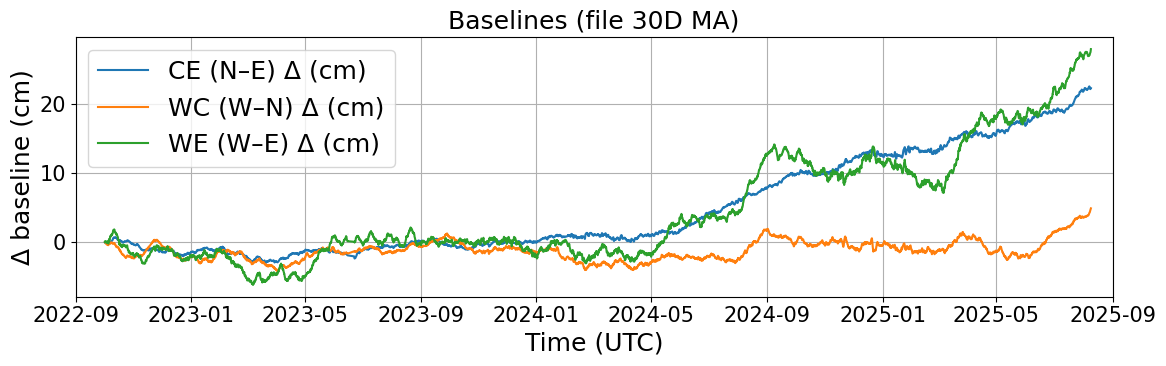

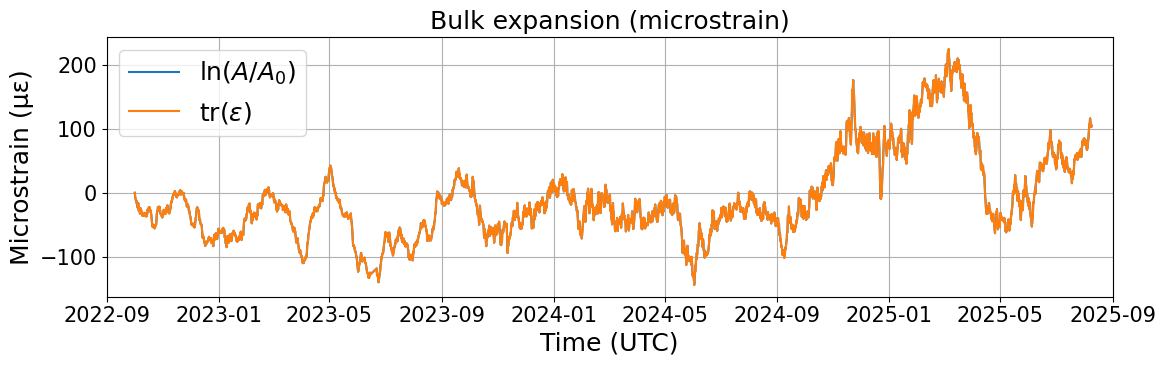

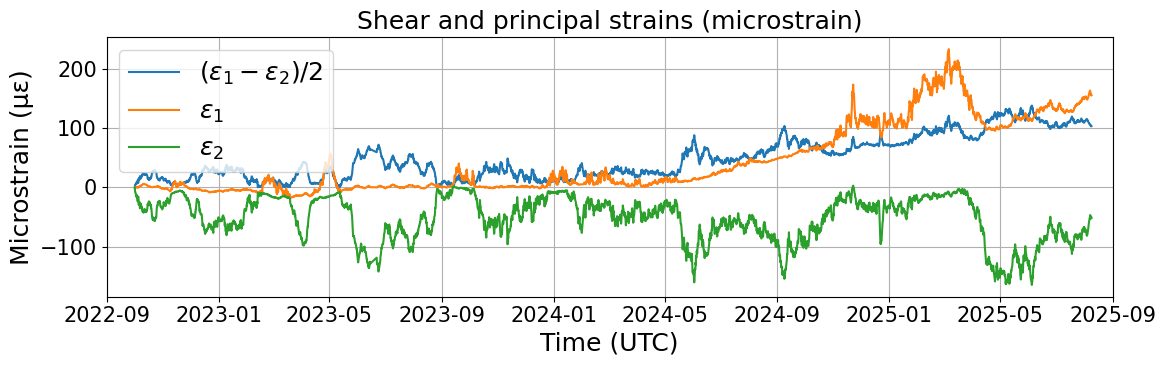

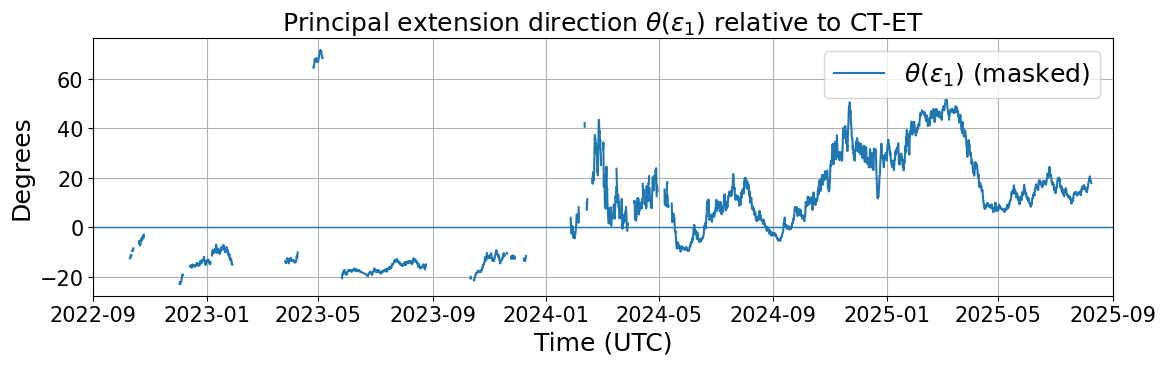

In [96]:
# =========================
# Plot settings: common time axis + microstrain scaling
# =========================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# Global matplotlib font sizes (18 pt everywhere)
# Run this once near the top of your notebook before plotting
# =========================
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 18,          # base
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 18,
})


# Common time window
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

# Convert strain -> microstrain
MICRO = 1e6

# Convenience: view restricted to common window (keeps DatetimeIndex)
dfp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()

print("Plot window rows:", len(dfp), "from", dfp.index.min(), "to", dfp.index.max())

plt.figure(figsize=(12,4))
plt.plot(dfp.index, dfp["CE_ma_cm"] - dfp["CE_ma_cm"].dropna().iloc[0], label="CE (N–E) Δ (cm)")
plt.plot(dfp.index, dfp["WC_ma_cm"] - dfp["WC_ma_cm"].dropna().iloc[0], label="WC (W–N) Δ (cm)")
plt.plot(dfp.index, dfp["WE_ma_cm"] - dfp["WE_ma_cm"].dropna().iloc[0], label="WE (W–E) Δ (cm)")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Δ baseline (cm)")
plt.title("Baselines (file 30D MA)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(dfp.index, MICRO * dfp["log_areal_strain"], label=r"$\ln(A/A_0)$")
plt.plot(dfp.index, MICRO * dfp["dilatation"], label=r"$ \mathrm{tr}(\varepsilon)$")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Bulk expansion (microstrain)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(dfp.index, MICRO * dfp["max_shear"], label=r"$(\varepsilon_1-\varepsilon_2)/2$")
plt.plot(dfp.index, MICRO * dfp["eps1"], label=r"$\varepsilon_1$")
plt.plot(dfp.index, MICRO * dfp["eps2"], label=r"$\varepsilon_2$")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Shear and principal strains (microstrain)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(dfp.index, dfp["theta_eps1_deg_masked"], label=r"$\theta(\varepsilon_1)$ (masked)")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Degrees")
plt.title(r"Principal extension direction $\theta(\varepsilon_1)$ relative to CT-ET")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()





In [110]:
# =========================
# Plot anisotropy ratio R(t) = [(ε1-ε2)/2] / tr(ε)
# (dimensionless) on the common time axis
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Common time window
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

dfp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()

# Components
shear = dfp["max_shear"].astype(float)          # (ε1-ε2)/2
bulk  = dfp["dilatation"].astype(float)         # tr(ε)

# Avoid blow-ups when bulk ~ 0
bulk_eps = 1e-12
R = (shear / np.where(np.abs(bulk) > bulk_eps, bulk, np.nan))
R = pd.Series(R, index=dfp.index, name="R_anisotropy")

plt.figure(figsize=(12,4))
plt.plot(R.index, R, label=r"$R(t)=\frac{(\varepsilon_1-\varepsilon_2)/2}{\mathrm{tr}(\varepsilon)}$")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Shear / bulk (dimensionless)")
plt.title("Directional vs bulk deformation ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'max_shear'

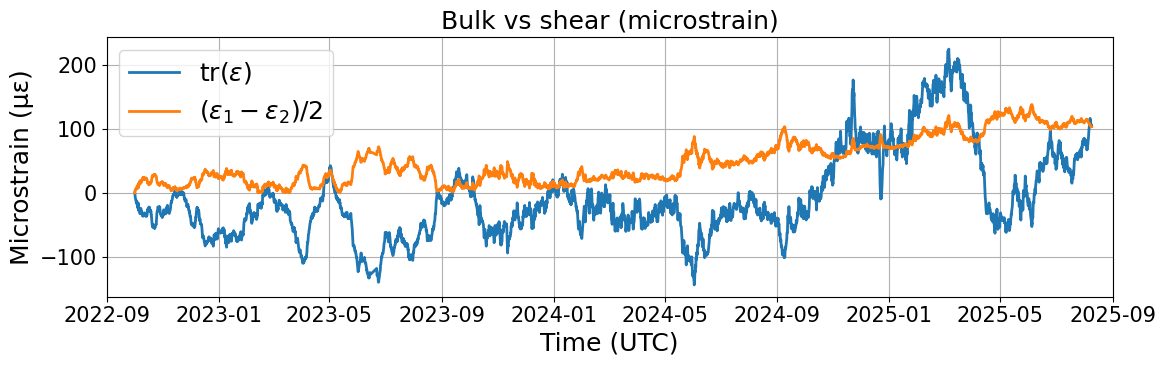

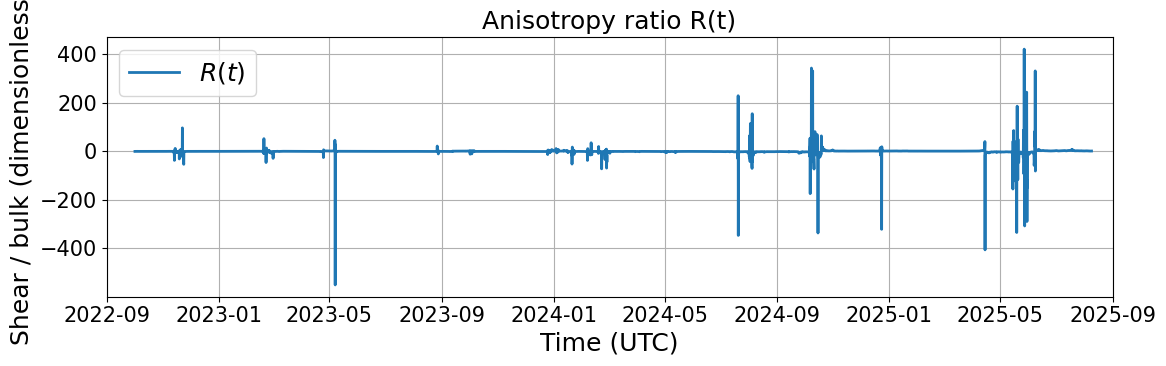

In [61]:
# =========================
# Optional: plot bulk & shear (microstrain) together with R(t)
# =========================
MICRO = 1e6

plt.figure(figsize=(12,4))
plt.plot(dfp.index, MICRO*bulk,  label=r"$\mathrm{tr}(\varepsilon)$", linewidth=2)
plt.plot(dfp.index, MICRO*shear, label=r"$(\varepsilon_1-\varepsilon_2)/2$", linewidth=2)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Bulk vs shear (microstrain)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(R.index, R, label=r"$R(t)$", linewidth=2)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Shear / bulk (dimensionless)")
plt.title("Anisotropy ratio R(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


107-day fitted amplitude: 28.7 με
R^2 for [linear trend + 107.3d cycle] on full series: 0.419


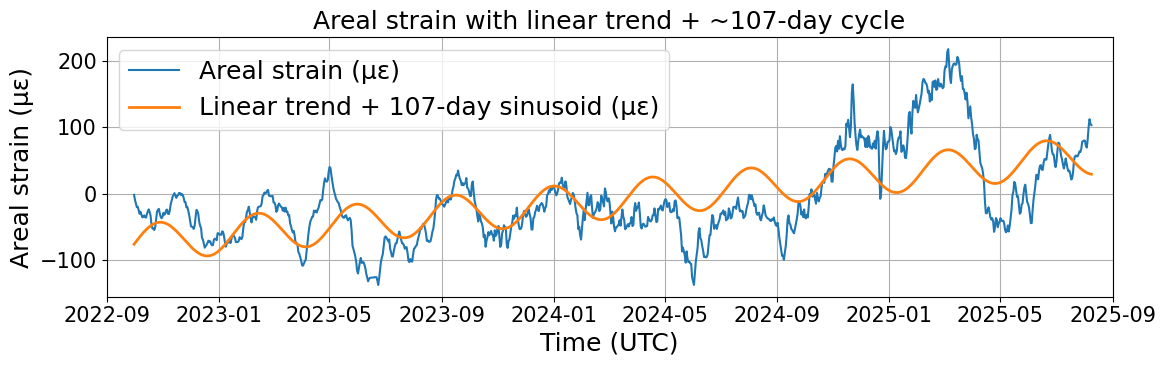

In [83]:
"""
Areal strain + (linear trend + ~107-day cycle) overlay

Requires:
  pip install pandas numpy matplotlib

Input:
  axial_triangle_area_areal_strain_from_baseline_30DMA.csv
  (expects a 'time_utc' column and either 'areal_strain_30Dma' OR 'A_30Dma_cm2')
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
AREA_FILE = "axial_triangle_area_areal_strain_excl_first30d.csv"
PERIOD_DAYS = 107.3          # "107-ish" cycle period
RESAMPLE = "1D"              # FFT/fit is easiest on uniform grid; 1 day is fine
TITLE = "Areal strain with linear trend + ~107-day cycle"
# Common time window
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

# =========================
# LOAD + BUILD AREAL STRAIN
# =========================
df = pd.read_csv(AREA_FILE)

if "time_utc" not in df.columns:
    raise ValueError("Expected a 'time_utc' column in the CSV.")

df["time_utc"] = pd.to_datetime(df["time_utc"], utc=True, errors="coerce")
df = df.dropna(subset=["time_utc"]).sort_values("time_utc").set_index("time_utc")

# Prefer areal strain column if present; otherwise compute from area
if "areal_strain" in df.columns:
    s = pd.to_numeric(df["areal_strain"], errors="coerce")
elif "A_cm2" in df.columns:
    A = pd.to_numeric(df["A_cm2"], errors="coerce").dropna()
    A0 = A.iloc[0]
    s = (A / A0) - 1.0
else:
    raise ValueError("Need either 'areal_strain_30Dma' or 'A_30Dma_cm2' in the CSV.")

s = s.dropna().sort_index()

# =========================
# RESAMPLE TO UNIFORM GRID
# =========================
s_daily = s.resample(RESAMPLE).mean().interpolate("time")
y = s_daily.to_numpy()  # unitless
t_sec = (s_daily.index - s_daily.index[0]).total_seconds().to_numpy()  # seconds since start

# =========================
# FIT: LINEAR TREND
# y ≈ a + b t
# =========================
Xtrend = np.column_stack([np.ones_like(t_sec), t_sec])
a, b = np.linalg.lstsq(Xtrend, y, rcond=None)[0]
trend = a + b * t_sec

# =========================
# FIT: 107-day SINUSOID ON RESIDUAL
# residual = y - trend ≈ A sin(wt) + B cos(wt)
# =========================
w = 2 * np.pi / (PERIOD_DAYS * 86400.0)  # rad/sec
S = np.sin(w * t_sec)
C = np.cos(w * t_sec)
resid = y - trend

Xcyc = np.column_stack([S, C])
A_sin, B_cos = np.linalg.lstsq(Xcyc, resid, rcond=None)[0]
cycle = A_sin * S + B_cos * C

model = trend + cycle

amp = np.sqrt(A_sin**2 + B_cos**2)        # unitless amplitude (same units as y)
amp_micro = amp * 1e6

# R^2 on full (non-detrended) y
ss_tot = np.sum((y - y.mean())**2)
ss_res = np.sum((y - model)**2)
r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

print(f"107-day fitted amplitude: {amp_micro:.1f} με")
print(f"R^2 for [linear trend + {PERIOD_DAYS:.1f}d cycle] on full series: {r2:.3f}")

# =========================
# PLOT (TOP PLOT YOU ASKED)
# =========================
plt.figure(figsize=(12, 4))
plt.plot(s_daily.index, y * 1e6, label="Areal strain (με)")
plt.plot(s_daily.index, model * 1e6, label=f"Linear trend + {PERIOD_DAYS:1.0f}-day sinusoid (με)", linewidth=2)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Areal strain (με)")
plt.title(TITLE)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


EW-frame strain computed.
Reference epoch: 2022-10-01 19:30:00+00:00
Shear mask threshold: 2.214981234003936e-05


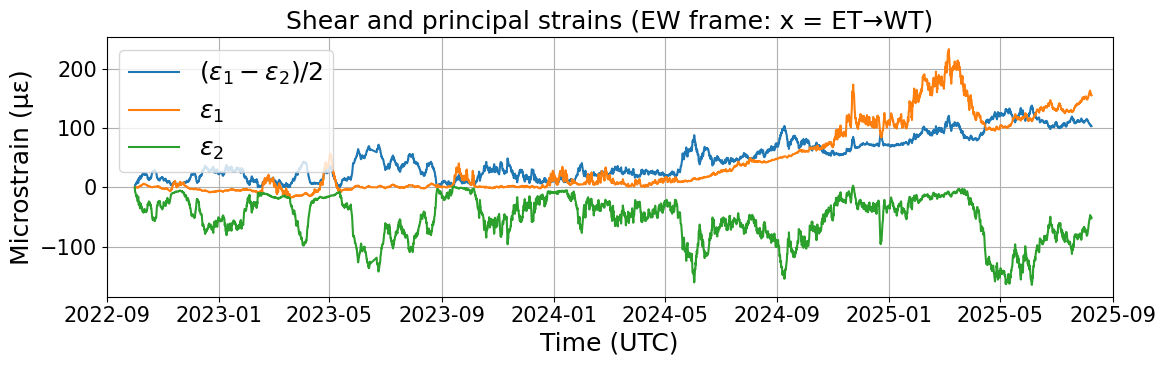

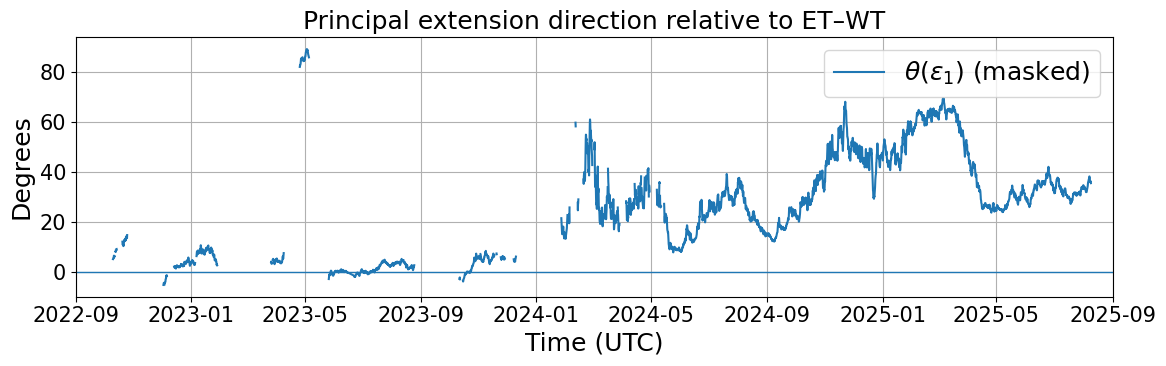

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# EW-frame strain from triangle baselines (ET–WT is x-axis)
# Requires df with columns: CE_ma_cm, WC_ma_cm, WE_ma_cm
# ------------------------------------------------------------

# If you haven't set these yet, keep these defaults:
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")
MICRO = 1e6

def embed_triangle_EW(CE: float, WC: float, WE: float):
    """
    Embed triangle in 2D with:
      E at (0,0)
      W at (WE,0)   <-- EW baseline is the x-axis
      N at (xN,yN)
    using:
      CE = N–E
      WC = W–N
      WE = W–E

    Returns (xN, yN) or (nan, nan) if invalid geometry.
    """
    EN, WN, EW = CE, WC, WE

    if not (np.isfinite(EN) and np.isfinite(WN) and np.isfinite(EW)):
        return np.nan, np.nan
    if EN <= 0 or WN <= 0 or EW <= 0:
        return np.nan, np.nan
    if (EN + WN <= EW) or (EN + EW <= WN) or (WN + EW <= EN):
        return np.nan, np.nan

    xN = (EN*EN + EW*EW - WN*WN) / (2.0 * EW)
    y2 = EN*EN - xN*xN
    if y2 < 0:
        if y2 > -1e-6:
            y2 = 0.0
        else:
            return np.nan, np.nan

    return xN, np.sqrt(y2)  # choose +sqrt for consistent orientation

# ---- sanity checks ----
required = ["CE_ma_cm", "WC_ma_cm", "WE_ma_cm"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"df is missing required columns: {missing}")

# Define sides (in cm)
a = df["CE_ma_cm"].astype(float)  # EN
b = df["WC_ma_cm"].astype(float)  # WN
c = df["WE_ma_cm"].astype(float)  # EW

# ---- find reference epoch (first valid geometry) ----
ref_t = None
for ts in df.index:
    xN, yN = embed_triangle_EW(float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts]))
    if np.isfinite(xN) and np.isfinite(yN):
        ref_t = ts
        break
if ref_t is None:
    raise RuntimeError("No valid triangle geometry found. Check baseline values/time alignment.")

CE0, WC0, WE0 = float(a.loc[ref_t]), float(b.loc[ref_t]), float(c.loc[ref_t])
xN0, yN0 = embed_triangle_EW(CE0, WC0, WE0)

# Reference edge matrix: columns are (W-E) and (N-E)
X0 = np.column_stack([np.array([WE0, 0.0]), np.array([xN0, yN0])])
X0_inv = np.linalg.inv(X0)

# ---- compute F, small strain eps, principals ----
n = len(df)
detF   = np.full(n, np.nan)
eps_xx = np.full(n, np.nan)
eps_yy = np.full(n, np.nan)
eps_xy = np.full(n, np.nan)
eps1   = np.full(n, np.nan)
eps2   = np.full(n, np.nan)

for i, ts in enumerate(df.index):
    CEi, WCi, WEi = float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts])
    xNi, yNi = embed_triangle_EW(CEi, WCi, WEi)
    if not (np.isfinite(xNi) and np.isfinite(yNi)):
        continue

    X = np.column_stack([np.array([WEi, 0.0]), np.array([xNi, yNi])])
    F = X @ X0_inv
    detF[i] = np.linalg.det(F)

    U = F - np.eye(2)
    eps = 0.5 * (U + U.T)  # small-strain tensor

    eps_xx[i], eps_yy[i], eps_xy[i] = eps[0,0], eps[1,1], eps[0,1]

    w = np.linalg.eigvalsh(eps)  # ascending
    eps2[i], eps1[i] = w[0], w[1]

# Write EW-frame results into df
df["detF_EWframe"] = detF
df["log_detF_EWframe"] = np.log(detF)

df["eps_xx_EWframe"] = eps_xx
df["eps_yy_EWframe"] = eps_yy
df["eps_xy_EWframe"] = eps_xy
df["eps1_EWframe"]   = eps1
df["eps2_EWframe"]   = eps2

df["dilatation_EWframe"] = df["eps_xx_EWframe"] + df["eps_yy_EWframe"]
df["max_shear_EWframe"]  = 0.5 * (df["eps1_EWframe"] - df["eps2_EWframe"])

# Principal direction relative to EW (x-axis), wrapped [-90, 90]
theta = 0.5 * np.arctan2(
    2.0 * df["eps_xy_EWframe"].to_numpy(float),
    (df["eps_xx_EWframe"].to_numpy(float) - df["eps_yy_EWframe"].to_numpy(float))
)
theta_deg = np.degrees(theta)
df["theta_eps1_deg_rel_EW"] = ((theta_deg + 90.0) % 180.0) - 90.0

# Mask angle when shear is tiny (direction unstable)
shear_pos = df["max_shear_EWframe"].dropna()
shear_pos = shear_pos[shear_pos > 0]
thr = max(np.percentile(shear_pos, 30), 2e-6) if len(shear_pos) else 2e-6
df["theta_eps1_deg_masked_EW"] = df["theta_eps1_deg_rel_EW"].where(df["max_shear_EWframe"] >= thr)

print("EW-frame strain computed.")
print("Reference epoch:", ref_t)
print("Shear mask threshold:", thr)

# ---- rebuild plotting subset dfp AFTER adding columns ----
dfp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()

# ---- plot: shear + principal strains (EW frame) ----
plt.figure(figsize=(12,4))
plt.plot(dfp.index, MICRO * dfp["max_shear_EWframe"], label=r"$(\varepsilon_1-\varepsilon_2)/2$")
plt.plot(dfp.index, MICRO * dfp["eps1_EWframe"], label=r"$\varepsilon_1$")
plt.plot(dfp.index, MICRO * dfp["eps2_EWframe"], label=r"$\varepsilon_2$")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Shear and principal strains (EW frame: x = ET→WT)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---- plot: principal direction relative to EW ----
plt.figure(figsize=(12,4))
plt.plot(dfp.index, dfp["theta_eps1_deg_masked_EW"], label=r"$\theta(\varepsilon_1)$ (masked)")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Degrees")
plt.title(r"Principal extension direction relative to ET–WT")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


30D residual std (median, cm): {'CE': 6.036540301086256, 'WC': 9.449011781826787, 'WE': 16.060485517724523}
lag-1 rho: {'CE': 0.359753909271167, 'WC': 0.2960041693598755, 'WE': 0.20948832734660433}
Neff(30D): {'CE': 84.75378930365517, 'WC': 97.77688414213344, 'WE': 117.64652693240456}
SE of 30D mean baseline (cm): {'CE': 0.655705070751134, 'WC': 0.9555827333210652, 'WE': 1.4807069495607423}
sigma[ln(A/A0)] median (microstrain): 59.923474454635134


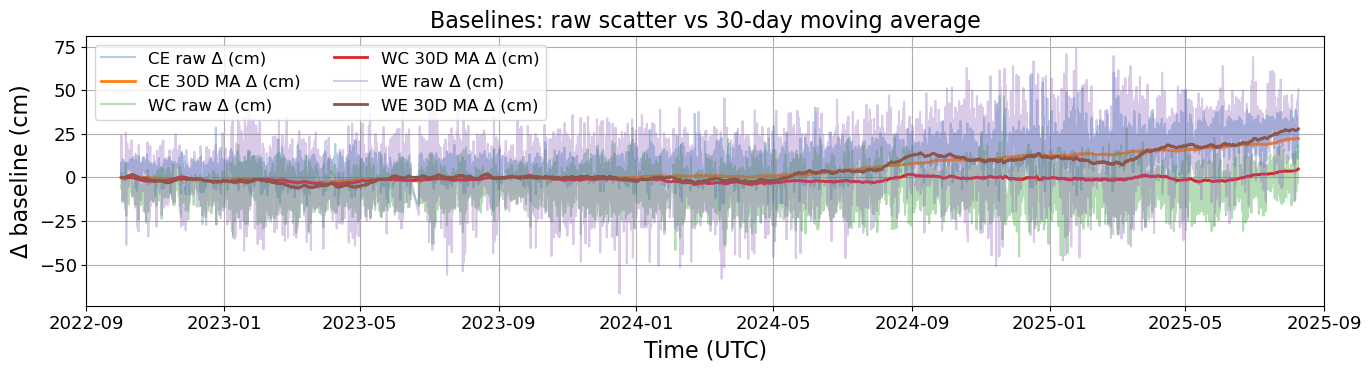

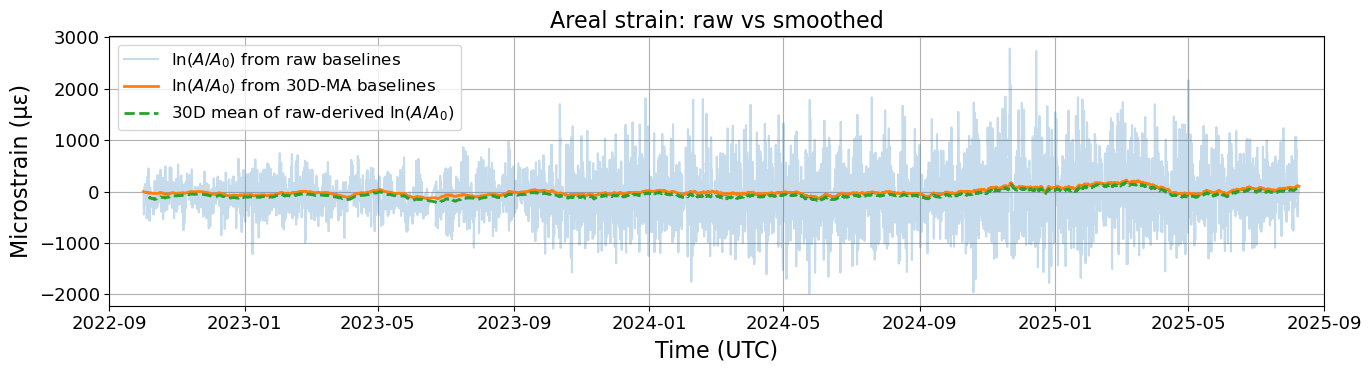

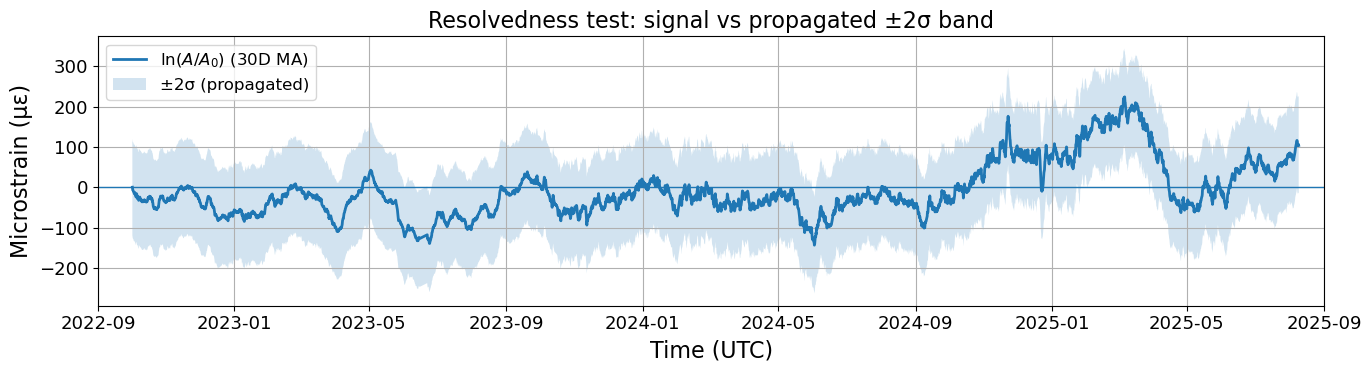

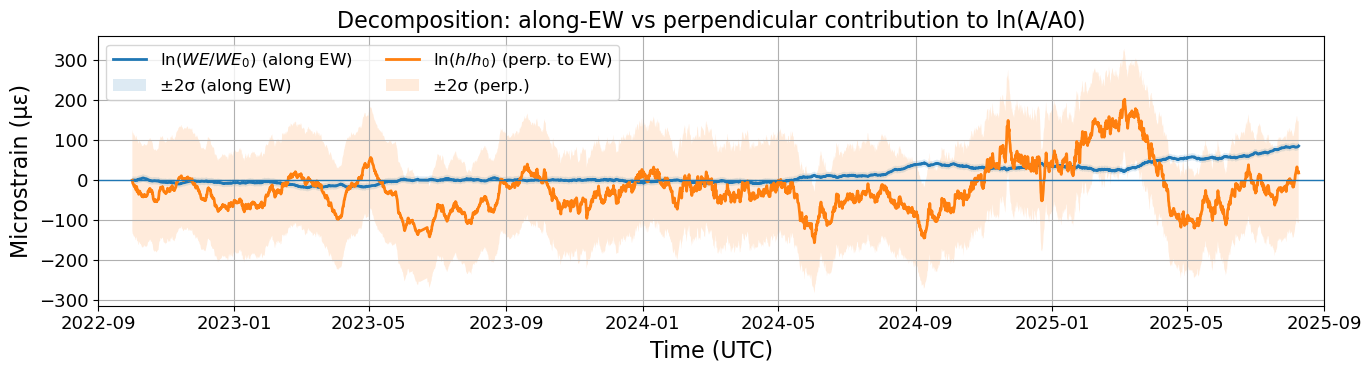

Saved plots in: arealstrain_diagnostics_outputs


In [112]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# --------------------------
# Inputs (your uploaded files)
# --------------------------
CE_BASELINE_CSV = "CE_distance_corrected.csv"
WC_BASELINE_CSV = "WC_distance_corrected.csv"
WE_BASELINE_CSV = "WE_distance_corrected.csv"

RAW_COL = "Distance (cm)"
MA_COL  = "Moving Average (cm)"

ASOF_TOLERANCE = "2H"
EXCLUDE_FIRST_DAYS = 30

TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

OUTDIR = "arealstrain_diagnostics_outputs"
os.makedirs(OUTDIR, exist_ok=True)

MICRO = 1e6

# --------------------------
# Helpers (from your style)
# --------------------------
def find_time_column(df):
    for c in df.columns:
        lc = c.lower()
        if any(k in lc for k in ["record time", "time", "date", "datetime", "timestamp"]):
            return c
    return df.columns[0]

def read_time_indexed_csv(path):
    df = pd.read_csv(path)
    tcol = find_time_column(df)
    df[tcol] = pd.to_datetime(df[tcol], utc=True, errors="coerce")
    df = df.dropna(subset=[tcol]).sort_values(tcol).set_index(tcol)
    df = df.groupby(level=0).mean(numeric_only=True)
    return df

def merge_asof_series(master_index, series, tolerance="2H"):
    left = pd.DataFrame({"time": pd.to_datetime(master_index, utc=True)}).sort_values("time")
    right = series.dropna().reset_index()
    right.columns = ["time_r", series.name]
    right = right.sort_values("time_r")
    out = pd.merge_asof(
        left, right,
        left_on="time", right_on="time_r",
        direction="nearest",
        tolerance=pd.Timedelta(tolerance)
    )
    out = out.drop(columns=["time_r"])
    return out.set_index("time")[series.name]

def heron_area(a,b,c):
    s = 0.5*(a+b+c)
    A2 = s*(s-a)*(s-b)*(s-c)
    return np.sqrt(np.maximum(A2, 0.0))

def lag1_autocorr(x):
    x = pd.Series(x).dropna().values
    if len(x) < 3:
        return np.nan
    x0, x1 = x[:-1], x[1:]
    if np.std(x0)==0 or np.std(x1)==0:
        return np.nan
    return np.corrcoef(x0, x1)[0,1]

def neff_ar1(N, rho):
    if not np.isfinite(rho):
        return N
    return N * (1-rho)/(1+rho)

# --------------------------
# Load and align baselines
# --------------------------
ce = read_time_indexed_csv(CE_BASELINE_CSV)
wc = read_time_indexed_csv(WC_BASELINE_CSV)
we = read_time_indexed_csv(WE_BASELINE_CSV)

CE_raw = pd.to_numeric(ce[RAW_COL], errors="coerce").rename("CE_raw_cm").dropna()
WC_raw = pd.to_numeric(wc[RAW_COL], errors="coerce").rename("WC_raw_cm").dropna()
WE_raw = pd.to_numeric(we[RAW_COL], errors="coerce").rename("WE_raw_cm").dropna()

CE_ma  = pd.to_numeric(ce[MA_COL],  errors="coerce").rename("CE_ma_cm").dropna()
WC_ma  = pd.to_numeric(wc[MA_COL],  errors="coerce").rename("WC_ma_cm").dropna()
WE_ma  = pd.to_numeric(we[MA_COL],  errors="coerce").rename("WE_ma_cm").dropna()

tline = CE_ma.index
WC_ma_a  = merge_asof_series(tline, WC_ma,  tolerance=ASOF_TOLERANCE)
WE_ma_a  = merge_asof_series(tline, WE_ma,  tolerance=ASOF_TOLERANCE)
WC_raw_a = merge_asof_series(tline, WC_raw, tolerance=ASOF_TOLERANCE)
WE_raw_a = merge_asof_series(tline, WE_raw, tolerance=ASOF_TOLERANCE)
CE_raw_a = CE_raw.reindex(tline)

baseline = pd.DataFrame({
    "CE_ma_cm": CE_ma.reindex(tline),
    "WC_ma_cm": WC_ma_a,
    "WE_ma_cm": WE_ma_a,
    "CE_raw_cm": CE_raw_a,
    "WC_raw_cm": WC_raw_a,
    "WE_raw_cm": WE_raw_a,
}).dropna().sort_index()

# Exclude first N days (your approach)
cut = baseline.index.min() + pd.Timedelta(days=EXCLUDE_FIRST_DAYS)
df = baseline.loc[baseline.index >= cut].copy()

# --------------------------
# Areal strain from MA + raw
# --------------------------
A_ma = heron_area(df["CE_ma_cm"], df["WC_ma_cm"], df["WE_ma_cm"])
A0_ma = A_ma.dropna().iloc[0]
df["lnA_ma"] = np.log(A_ma / A0_ma)

A_raw = heron_area(df["CE_raw_cm"], df["WC_raw_cm"], df["WE_raw_cm"])
A0_raw = A_raw.dropna().iloc[0]
df["lnA_raw"] = np.log(A_raw / A0_raw)
df["lnA_raw_30Dmean"] = df["lnA_raw"].rolling("30D", min_periods=30).mean()

# --------------------------
# Estimate baseline noise from residuals (raw - MA)
# --------------------------
res_CE = (df["CE_raw_cm"] - df["CE_ma_cm"]).dropna()
res_WC = (df["WC_raw_cm"] - df["WC_ma_cm"]).dropna()
res_WE = (df["WE_raw_cm"] - df["WE_ma_cm"]).dropna()

std_CE_30D = res_CE.rolling("30D", min_periods=100).std()
std_WC_30D = res_WC.rolling("30D", min_periods=100).std()
std_WE_30D = res_WE.rolling("30D", min_periods=100).std()

rho_CE = lag1_autocorr(res_CE)
rho_WC = lag1_autocorr(res_WC)
rho_WE = lag1_autocorr(res_WE)

# Typical timestep (hours)
dt = np.median(np.diff(df.index.values).astype("timedelta64[s]").astype(float))
dt_hours = dt/3600.0
N30 = 30*24/dt_hours

Neff_CE = neff_ar1(N30, rho_CE)
Neff_WC = neff_ar1(N30, rho_WC)
Neff_WE = neff_ar1(N30, rho_WE)

typ_std_CE = float(std_CE_30D.median())
typ_std_WC = float(std_WC_30D.median())
typ_std_WE = float(std_WE_30D.median())

se_CE = typ_std_CE / np.sqrt(Neff_CE)
se_WC = typ_std_WC / np.sqrt(Neff_WC)
se_WE = typ_std_WE / np.sqrt(Neff_WE)

print("30D residual std (median, cm):", {"CE": typ_std_CE, "WC": typ_std_WC, "WE": typ_std_WE})
print("lag-1 rho:", {"CE": rho_CE, "WC": rho_WC, "WE": rho_WE})
print("Neff(30D):", {"CE": Neff_CE, "WC": Neff_WC, "WE": Neff_WE})
print("SE of 30D mean baseline (cm):", {"CE": se_CE, "WC": se_WC, "WE": se_WE})

# --------------------------
# Propagate baseline SE -> sigma[ln(A/A0)] using finite differences
# --------------------------
delta = 0.1  # cm perturbation

def lnA_from_sides(a,b,c,A0):
    A = heron_area(a,b,c)
    return np.log(A/A0)

a = df["CE_ma_cm"].to_numpy(float)
b = df["WC_ma_cm"].to_numpy(float)
c = df["WE_ma_cm"].to_numpy(float)

dlnA_da = (lnA_from_sides(a+delta,b,c,A0_ma) - lnA_from_sides(a-delta,b,c,A0_ma))/(2*delta)
dlnA_db = (lnA_from_sides(a,b+delta,c,A0_ma) - lnA_from_sides(a,b-delta,c,A0_ma))/(2*delta)
dlnA_dc = (lnA_from_sides(a,b,c+delta,A0_ma) - lnA_from_sides(a,b,c-delta,A0_ma))/(2*delta)

df["sigma_lnA_est"] = np.sqrt((dlnA_da*se_CE)**2 + (dlnA_db*se_WC)**2 + (dlnA_dc*se_WE)**2)

print("sigma[ln(A/A0)] median (microstrain):", float(np.nanmedian(df["sigma_lnA_est"])*MICRO))

# --------------------------
# EW-frame decomposition: A = 0.5*WE*h  -> lnA = lnWE + lnh
# --------------------------
WE = df["WE_ma_cm"].to_numpy(float)
A  = A_ma.to_numpy(float)
h  = (2*A)/WE

df["h_EW_cm"] = h

WE0 = df["WE_ma_cm"].dropna().iloc[0]
h0  = df["h_EW_cm"][np.isfinite(df["h_EW_cm"])].iloc[0]

df["lnWE"] = np.log(df["WE_ma_cm"]/WE0)
df["lnh"]  = np.log(df["h_EW_cm"]/h0)

# Uncertainty for lnWE and lnh
df["sigma_lnWE"] = se_WE / df["WE_ma_cm"].to_numpy(float)

def lnh_from_sides(a,b,c,h0):
    A = heron_area(a,b,c)
    h = (2*A)/c
    return np.log(h/h0)

dlnh_da = (lnh_from_sides(a+delta,b,c,h0) - lnh_from_sides(a-delta,b,c,h0))/(2*delta)
dlnh_db = (lnh_from_sides(a,b+delta,c,h0) - lnh_from_sides(a,b-delta,c,h0))/(2*delta)
dlnh_dc = (lnh_from_sides(a,b,c+delta,h0) - lnh_from_sides(a,b,c-delta,h0))/(2*delta)
df["sigma_lnh"] = np.sqrt((dlnh_da*se_CE)**2 + (dlnh_db*se_WC)**2 + (dlnh_dc*se_WE)**2)

# --------------------------
# Plotting
# --------------------------
dfp = df.loc[(df.index>=TMIN) & (df.index<=TMAX)].copy()
x = dfp.index.to_pydatetime()

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
})

# 1) Baselines raw vs MA
plt.figure(figsize=(14,4))
for key in ["CE","WC","WE"]:
    raw = (dfp[f"{key}_raw_cm"] - dfp[f"{key}_raw_cm"].dropna().iloc[0]).to_numpy(float)
    ma  = (dfp[f"{key}_ma_cm"]  - dfp[f"{key}_ma_cm"].dropna().iloc[0]).to_numpy(float)
    plt.plot(x, raw, alpha=0.35, label=f"{key} raw Δ (cm)")
    plt.plot(x, ma,  linewidth=2.0, label=f"{key} 30D MA Δ (cm)")
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.xlabel("Time (UTC)"); plt.ylabel("Δ baseline (cm)")
plt.title("Baselines: raw scatter vs 30-day moving average")
plt.grid(True); plt.legend(ncol=2); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,"01_baselines_raw_vs_ma.png"), dpi=200)
plt.show()

# 2) Areal strain raw vs MA
plt.figure(figsize=(14,4))
plt.plot(x, (MICRO*dfp["lnA_raw"]).to_numpy(float), alpha=0.25, label=r"$\ln(A/A_0)$ from raw baselines")
plt.plot(x, (MICRO*dfp["lnA_ma"]).to_numpy(float), linewidth=2.0, label=r"$\ln(A/A_0)$ from 30D-MA baselines")
plt.plot(x, (MICRO*dfp["lnA_raw_30Dmean"]).to_numpy(float), linestyle="--", linewidth=2.0,
         label=r"30D mean of raw-derived $\ln(A/A_0)$")
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.xlabel("Time (UTC)"); plt.ylabel("Microstrain (με)")
plt.title("Areal strain: raw vs smoothed")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,"02_lnA_raw_vs_ma.png"), dpi=200)
plt.show()

# 3) Areal strain with ±2σ band
plt.figure(figsize=(14,4))
y = (MICRO*dfp["lnA_ma"]).to_numpy(float)
sig = (MICRO*dfp["sigma_lnA_est"]).to_numpy(float)
plt.plot(x, y, linewidth=2.0, label=r"$\ln(A/A_0)$ (30D MA)")
plt.fill_between(x, y-2*sig, y+2*sig, alpha=0.2, label=r"±2σ (propagated)")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.xlabel("Time (UTC)"); plt.ylabel("Microstrain (με)")
plt.title("Resolvedness test: signal vs propagated ±2σ band")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,"03_lnA_with_uncertainty.png"), dpi=200)
plt.show()

# 4) Perpendicular distance (height to EW) + decomposition
plt.figure(figsize=(14,4))
plt.plot(x, (MICRO*dfp["lnWE"]).to_numpy(float), linewidth=2, label=r"$\ln(WE/WE_0)$ (along EW)")
plt.fill_between(x,
                 (MICRO*(dfp["lnWE"]-2*dfp["sigma_lnWE"])).to_numpy(float),
                 (MICRO*(dfp["lnWE"]+2*dfp["sigma_lnWE"])).to_numpy(float),
                 alpha=0.15, label="±2σ (along EW)")
plt.plot(x, (MICRO*dfp["lnh"]).to_numpy(float), linewidth=2, label=r"$\ln(h/h_0)$ (perp. to EW)")
plt.fill_between(x,
                 (MICRO*(dfp["lnh"]-2*dfp["sigma_lnh"])).to_numpy(float),
                 (MICRO*(dfp["lnh"]+2*dfp["sigma_lnh"])).to_numpy(float),
                 alpha=0.15, label="±2σ (perp.)")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.xlabel("Time (UTC)"); plt.ylabel("Microstrain (με)")
plt.title("Decomposition: along-EW vs perpendicular contribution to ln(A/A0)")
plt.grid(True); plt.legend(ncol=2); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,"04_decomposition_along_vs_perp.png"), dpi=200)
plt.show()

print("Saved plots in:", OUTDIR)
